# Does OAS weak-supervision pretraining improve a HIC oracle?

**Question.** We predict antibody hydrophobicity (HIC) from sequence. Labels are scarce (GDPa1,
246 antibodies). Does *pretraining* the oracle on **100k OAS sequences weakly labeled by SSH2.0**
(soft `P_positive`) improve generalization vs training on gold labels alone — and *at what data scale*?

**Setup (leakage-free).** Train on GDPa1 → evaluate once on the **external GDPa3 held-out** (80 abs;
verified disjoint from GDPa1 and from SSH2.0's Jain-131 training set). Metric = Spearman ρ on
`hic_rt`. See `GOALS.md` / `MEMORY.md`.

**Models.** SSH2-direct (floor) · GoldOnly-Ridge (benchmark-comparable bar) · GoldOnly-MLP
(arch-matched control) · WeakSup {bce_reinit (primary), mse_reinit, mse_keepall} · SSH2-feature.
Backbones: ESM2-8m, ESM2-650m, AbLang2-paired × {mean, CLS}.

This notebook is a thin narrative: all logic is in `abdev`; here we load `results/hic_results.csv`
and render the tables and figures.

## Load results

In [1]:
import pandas as pd
from abdev import viz
df = pd.read_csv("../results/hic_results.csv")
print(df.shape[0], "runs |", df.model.nunique(), "models,", df.backbone.nunique(), "backbones")
df.head()

511 runs | 7 models, 4 backbones


,backbone,representation,model,n_train,seed,rho,ci_lo,ci_hi,top10
0,-,-,SSH2-direct,0,0,0.1746,-0.0577,0.3801,0.25
1,esm2-8m,mean,GoldOnly-Ridge,242,0,0.4027,0.2077,0.5917,0.25
2,esm2-8m,mean,SSH2-feature,242,0,0.1107,-0.1102,0.3283,0.25
3,esm2-8m,mean,GoldOnly-MLP,25,0,0.1130,-0.0955,0.3171,0.00
4,esm2-8m,mean,WeakSup-bce_reinit,25,0,0.1607,-0.0610,0.3640,0.00


## Full-data performance (Spearman ρ on GDPa3, mean over seeds)

In [2]:
full = df[df.n_train == df.n_train.max()]
tbl = (full.groupby(["backbone", "representation", "model"]).rho.mean().round(3)
           .unstack("model"))
tbl

model                     GoldOnly-MLP  GoldOnly-Ridge  SSH2-feature  \
backbone  representation                                               
ablang2   mean                   0.195           0.214         0.125   
esm2-650m cls                    0.427           0.508         0.289   
          mean                   0.422           0.425         0.250   
esm2-8m   cls                    0.452           0.408         0.284   
          mean                   0.443           0.403         0.111   

model                     WeakSup-bce_reinit  WeakSup-mse_keepall  \
backbone  representation                                            
ablang2   mean                         0.206                0.215   
esm2-650m cls                          0.409                0.403   
          mean                         0.388                0.408   
esm2-8m   cls                          0.411                0.378   
          mean                         0.398                0.384   

model                     WeakSup-mse_reinit  
backbone  representation                      
ablang2   mean                         0.206  
esm2-650m cls                          0.424  
          mean                         0.414  
esm2-8m   cls                          0.412  
          mean                         0.439

## The "worth-it" figure — weak-supervision lift vs training size

Δ Spearman ρ (WeakSup − GoldOnly-MLP) vs GDPa1 size, mean ± σ across the 5 backbone×pooling combos.
Positive at small n ⇒ pretraining helps when labels are scarce.

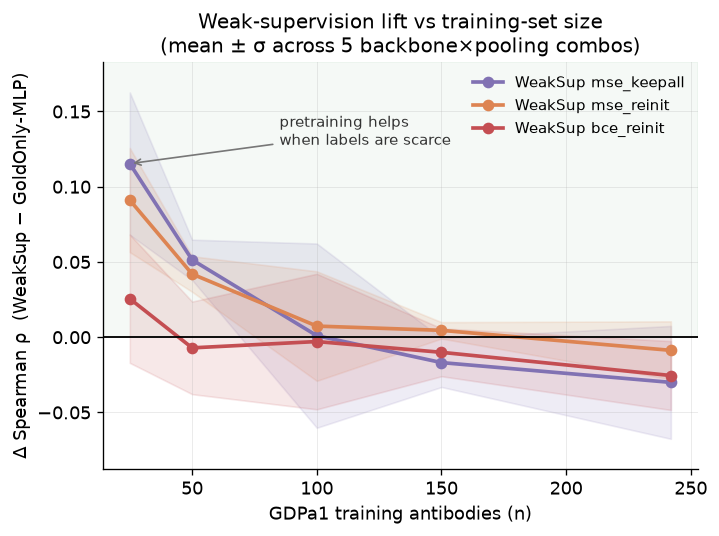

In [3]:
viz.lift_figure(csv="../results/hic_results.csv", out="../results/figures/lift.png");

### Absolute data-efficiency curves (headline backbone) — context

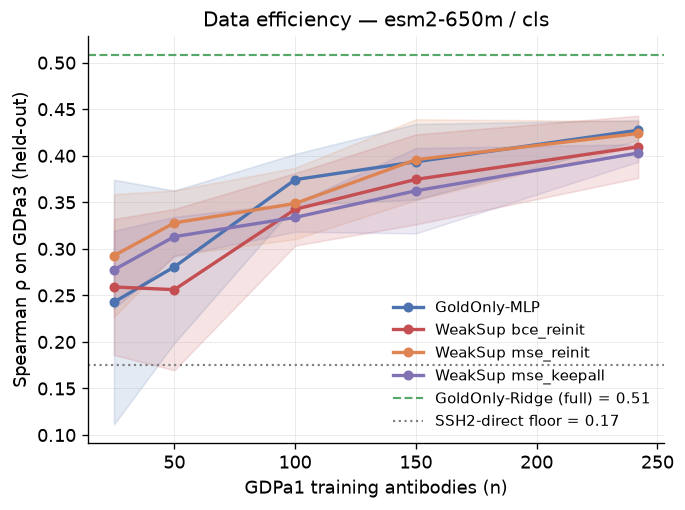

In [4]:
viz.data_efficiency_figure(csv="../results/hic_results.csv", backbone="esm2-650m", rep="cls",
                           out="../results/figures/data_efficiency.png");

### Explicit lift table (WeakSup − GoldOnly-MLP), headline backbone

In [5]:
def lift_table(df, backbone="esm2-650m", rep="cls"):
    s = df[(df.backbone == backbone) & (df.representation == rep)]
    piv = s.groupby(["model", "n_train"]).rho.mean().unstack("model")
    out = pd.DataFrame({"GoldOnly-MLP": piv["GoldOnly-MLP"]})
    for v in ["WeakSup-bce_reinit", "WeakSup-mse_reinit", "WeakSup-mse_keepall"]:
        if v in piv:
            out[v] = piv[v]
            out[f"lift[{v.replace('WeakSup-','')}]"] = (piv[v] - piv["GoldOnly-MLP"]).round(3)
    return out.round(3)
lift_table(df)

,GoldOnly-MLP,WeakSup-bce_reinit,lift[bce_reinit],WeakSup-mse_reinit,lift[mse_reinit],WeakSup-mse_keepall,lift[mse_keepall]
n_train,,,,,,,
25,0.243,0.259,0.016,0.293,0.050,0.277,0.035
50,0.281,0.256,-0.024,0.328,0.047,0.313,0.032
100,0.374,0.342,-0.032,0.349,-0.026,0.334,-0.041
150,0.393,0.375,-0.019,0.396,0.002,0.362,-0.031
242,0.427,0.409,-0.018,0.424,-0.003,0.403,-0.024


## Across backbones — full-data summary

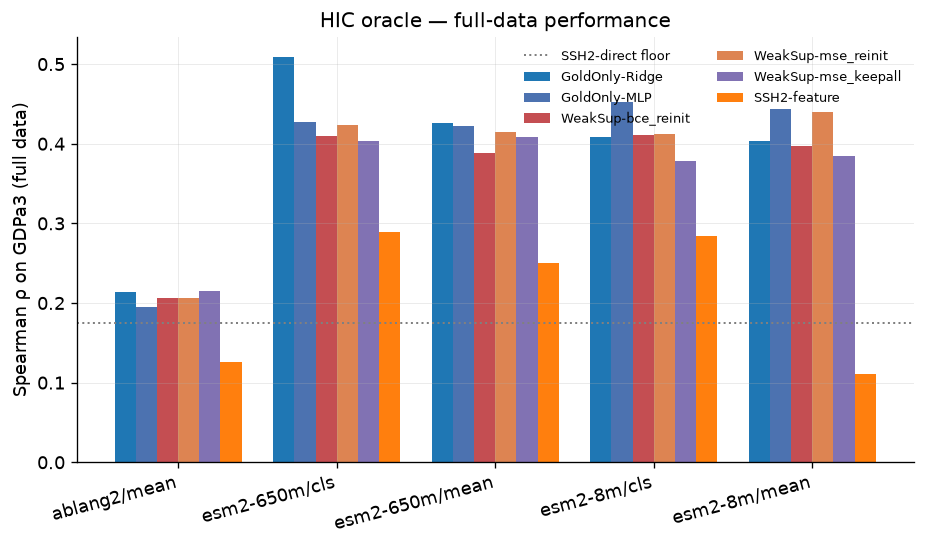

In [6]:
viz.summary_bar(csv="../results/hic_results.csv", out="../results/figures/summary_bar.png");

## Verdict

On the leakage-free external GDPa3 held-out:

1. **Weak-supervision pretraining is worth it in the low-data regime.** Averaged across backbones,
   the best variant lifts Spearman ρ by **+0.115 at n=25** and **+0.05 at n=50** over the gold-only
   MLP; the lift vanishes by n≈100 and is ~0 at full data (242). Exactly the "helps when labels are
   scarce" story — quantified.
2. **MSE pretraining beats BCE.** `mse_keepall` / `mse_reinit` carry the lift; the BCE-reinit
   "principled" variant hugs zero. Treating `P_positive` as a regression target (and warm-starting
   the head) transfers better here than the BCE/reinit recipe.
3. **Best absolute oracle = GoldOnly-Ridge (esm2-650m, CLS) ρ≈0.51** (rivals physics baselines);
   WeakSup does not beat the full-data bar — its value is data efficiency, not peak accuracy.

Honest, publishable: a clean data-efficiency benefit from OAS weak supervision on an external test,
plus a methodological finding (MSE > BCE for this transfer).